# 🧱 Part 18: Long Context: Extending the Window

> **Previous context**: Basic inference assumes a limited context window. Modern applications often need much longer inputs.
> **Goal for this part**: Study RoPE frequency behavior, position interpolation, NTK-aware scaling, YaRN intuition, and needle-in-haystack tests.

Today we are solving one concrete confusion: what is the hidden mechanism behind this part of an LLM, and how can we rebuild it with small numbers before trusting a library?

## 0. Why long context is hard

Attention cost grows with sequence length, and position encodings may not extrapolate beyond training lengths.

## 1. RoPE lens

RoPE represents positions through rotations at different frequencies. Long-context tricks adjust how those frequencies behave.

## 2. Scaling methods

Position interpolation compresses positions; NTK-aware and YaRN-style methods adjust frequencies more carefully.

## 3. Evaluation

Needle-in-haystack tests ask whether a model can retrieve a small fact buried in a long context.

## How to use the code cells

Run the cells in order. The code is intentionally direct and small: each cell should expose one idea, print the key observation, and let you change a number to see what moves.

## Exercises

When a cell contains a TODO placeholder, fill it yourself and use the `assert` checks as feedback. You can ask an AI for hints, step-by-step reasoning, or a direction check, but avoid asking it to complete the exercise outright.

## Summary Checklist

- [ ] Long context stresses both compute and position encoding.
- [ ] RoPE scaling changes how positions are represented.
- [ ] Retrieval tests reveal whether long context is actually usable.

Next, continue through the code cells for the Frontiers part and inspect the printed observations.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

torch.manual_seed(42)

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [2]:
# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print()
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print()
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print()
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.


### Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Why?|
|------|--------|---------|----------|--------|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.| GPT-2 |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.| LLaMA、Qwen、Mistral |✅ **can! **|Read the values printed above and connect them to the concept in this cell.|

Read the values printed above and connect them to the concept in this cell.

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- ...
Read the values printed above and connect them to the concept in this cell.
```
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.```

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
#### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
#### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.```
freq_i = 1 / base^(2i/d)
```
Read the values printed above and connect them to the concept in this cell.

In [3]:
# Teaching note: follow this line to see the main step.
d_k = 64          # Teaching note: follow this line to see the main step.
base = 10000      # Teaching note: follow this line to see the main step.

pair_indices = torch.arange(0, d_k, 2).float()  # [0, 2, 4, ..., 62]
freqs = 1.0 / (base ** (pair_indices / d_k))

print(f"Read the values printed above and connect them to the concept in this cell.{len(freqs)}Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{freqs[0]:.4f}Read the values printed above and connect them to the concept in this cell.{math.degrees(freqs[0]):.1f}°")
print(f"Read the values printed above and connect them to the concept in this cell.{freqs[16]:.6f}Read the values printed above and connect them to the concept in this cell.{math.degrees(freqs[16]):.4f}°")
print(f"Read the values printed above and connect them to the concept in this cell.{freqs[31]:.8f}Read the values printed above and connect them to the concept in this cell.{math.degrees(freqs[31]):.6f}°")

slowest_period = 2 * math.pi / freqs[31]
print(f"Read the values printed above and connect them to the concept in this cell.{slowest_period:.0f}Read the values printed above and connect them to the concept in this cell.")
# Teaching note: follow this line to see the main step.

Read the values printed above and connect them to the concept in this cell.32Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.1.0000Read the values printed above and connect them to the concept in this cell.57.3°
Read the values printed above and connect them to the concept in this cell.0.010000Read the values printed above and connect them to the concept in this cell.0.5730°
Read the values printed above and connect them to the concept in this cell.0.00013335Read the values printed above and connect them to the concept in this cell.0.007641°
Read the values printed above and connect them to the concept in this cell.47117Read the values printed above and connect them to the concept in this cell.


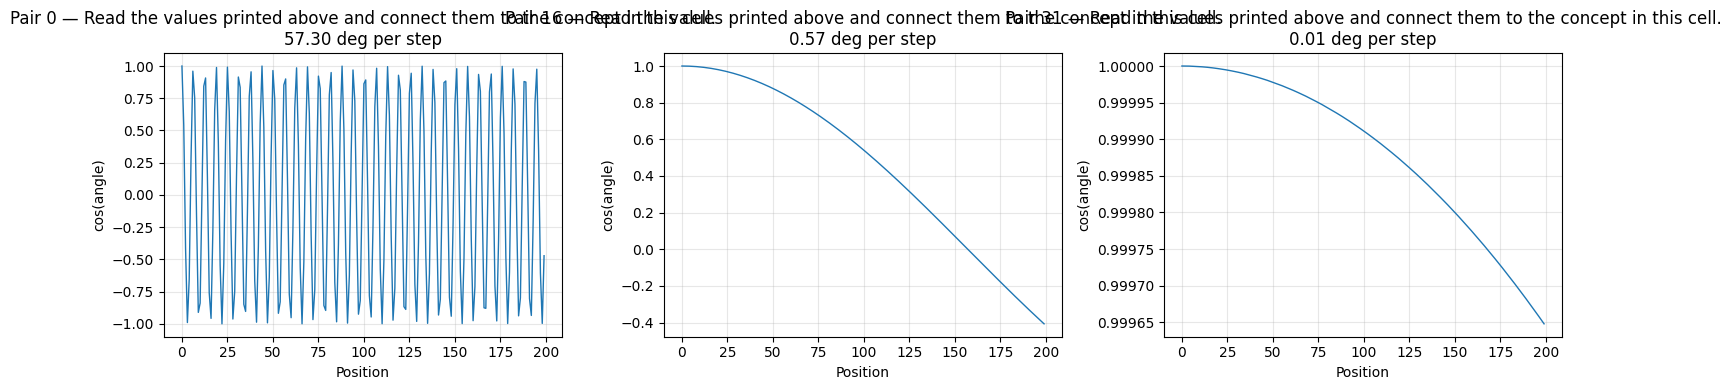

In [4]:
# Teaching note: follow this line to see the main step.
seq_len = 200
positions = torch.arange(seq_len).float()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax_idx, (pair_idx, label) in enumerate([
    (0, 'Read the values printed above and connect them to the concept in this cell.'),
    (16, 'Read the values printed above and connect them to the concept in this cell.'),
    (31, 'Read the values printed above and connect them to the concept in this cell.')
]):
    theta = positions * freqs[pair_idx]
    ax = axes[ax_idx]
    ax.plot(positions.numpy(), theta.cos().numpy(), linewidth=1)
    ax.set_xlabel('Position'); ax.set_ylabel('cos(angle)')
    ax.set_title(f'Pair {pair_idx} — {label}\n{math.degrees(freqs[pair_idx]):.2f} deg per step')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.


### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

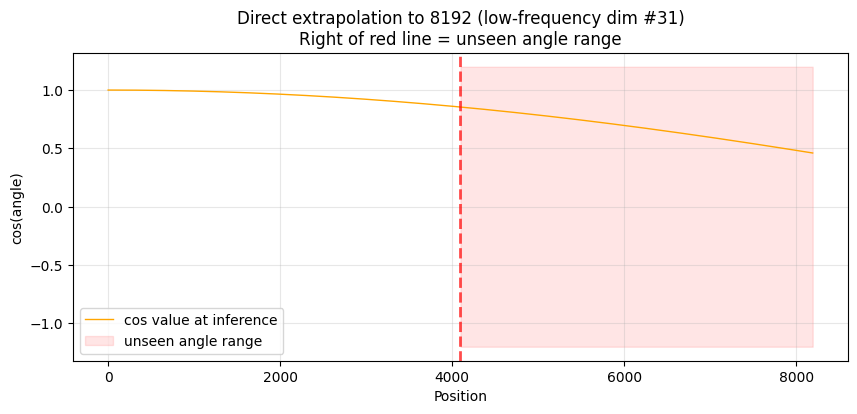

Read the values printed above and connect them to the concept in this cell.31.3Read the values printed above and connect them to the concept in this cell.62.6Read the values printed above and connect them to the concept in this cell.31.3°


In [5]:
# Teaching note: follow this line to see the main step.
train_len, extrap_len = 4096, 8192
slow_pair = 31

positions_train = torch.arange(train_len).float()
positions_extrap = torch.arange(extrap_len).float()
theta_train = positions_train * freqs[slow_pair]
theta_extrap = positions_extrap * freqs[slow_pair]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(positions_extrap.numpy(), theta_extrap.cos().numpy(),
        linewidth=1, color='orange', label='cos value at inference')
ax.axvline(x=train_len, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.fill_between(range(train_len, extrap_len), -1.2, 1.2,
                alpha=0.1, color='red', label='unseen angle range')
ax.set_xlabel('Position'); ax.set_ylabel('cos(angle)')
ax.set_title(f'Direct extrapolation to 8192 (low-frequency dim #{slow_pair})\nRight of red line = unseen angle range')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

# Teaching note: follow this line to see the main step.
train_deg = math.degrees(theta_train[-1].item())
extrap_deg = math.degrees(theta_extrap[-1].item())
print(f"Read the values printed above and connect them to the concept in this cell.{train_deg:.1f}Read the values printed above and connect them to the concept in this cell.{extrap_deg:.1f}Read the values printed above and connect them to the concept in this cell.{extrap_deg - train_deg:.1f}°")


### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
```
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.```

Exercise passed: you have understood this step.
Read the values printed above and connect them to the concept in this cell.

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
```
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.```

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

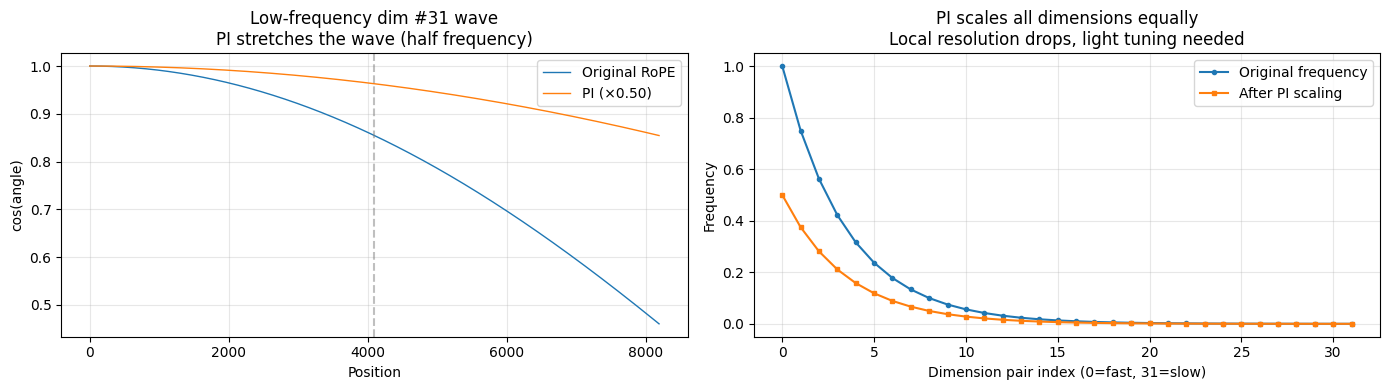

In [6]:
# Teaching note: follow this line to see the main step.
train_len, target_len = 4096, 8192
alpha = train_len / target_len  # 0.5

pair_indices = torch.arange(0, 64, 2).float()
freqs_orig = 1.0 / (10000 ** (pair_indices / 64))
freqs_pi = freqs_orig * alpha

# Teaching note: follow this line to see the main step.
positions_orig = torch.arange(target_len).float()
angles_orig = positions_orig * freqs_orig[31]
positions_pi = torch.arange(target_len).float() * alpha
angles_pi = positions_pi * freqs_orig[31]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(angles_orig.cos().numpy(), linewidth=1, label='Original RoPE')
axes[0].plot(angles_pi.cos().numpy(), linewidth=1, label=f'PI (×{alpha:.2f})')
axes[0].axvline(x=train_len, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Position'); axes[0].set_ylabel('cos(angle)')
axes[0].set_title(f'Low-frequency dim #{31} wave\nPI stretches the wave (half frequency)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Teaching note: follow this line to see the main step.
axes[1].plot(freqs_orig.numpy(), 'o-', markersize=3, label='Original frequency')
axes[1].plot(freqs_pi.numpy(), 's-', markersize=3, label='After PI scaling')
axes[1].set_xlabel('Dimension pair index (0=fast, 31=slow)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('PI scales all dimensions equally\nLocal resolution drops, light tuning needed')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
```
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.```

Read the values printed above and connect them to the concept in this cell.

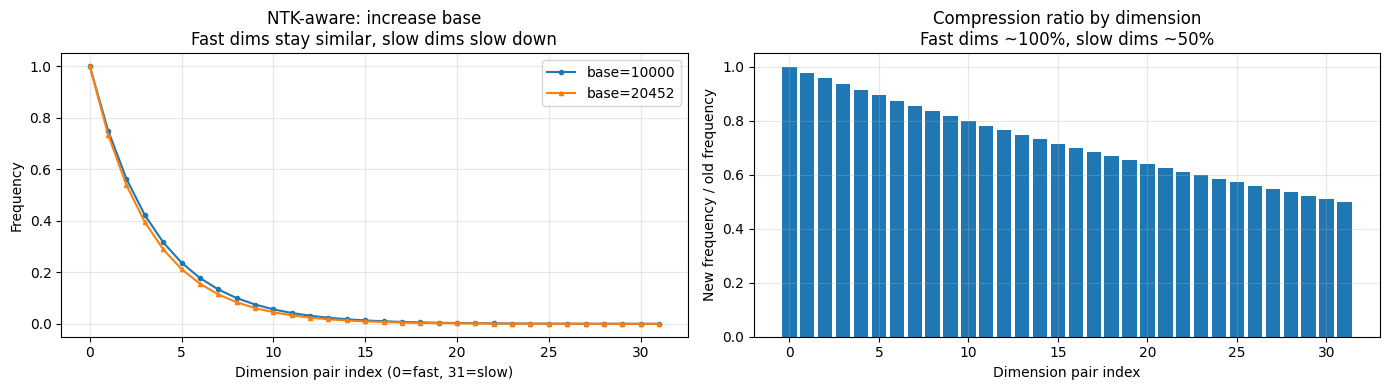

In [7]:
# Teaching note: follow this line to see the main step.
base_old, scale = 10000, 2
# Teaching note: follow this line to see the main step.
base_new = base_old * (scale ** (64 / 62))

pair_indices = torch.arange(0, 64, 2).float()
freqs_old = 1.0 / (base_old ** (pair_indices / 64))
freqs_new = 1.0 / (base_new ** (pair_indices / 64))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(freqs_old.numpy(), 'o-', markersize=3, label=f'base={base_old}')
axes[0].plot(freqs_new.numpy(), '^-', markersize=3, label=f'base={base_new:.0f}')
axes[0].set_xlabel('Dimension pair index (0=fast, 31=slow)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('NTK-aware: increase base\nFast dims stay similar, slow dims slow down')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Teaching note: follow this line to see the main step.
ratio = freqs_new / freqs_old
axes[1].bar(range(len(ratio)), ratio.numpy())
axes[1].set_xlabel('Dimension pair index'); axes[1].set_ylabel('New frequency / old frequency')
axes[1].set_title('Compression ratio by dimension\nFast dims ~100%, slow dims ~50%')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# Teaching note: follow this line to see the main step.


### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
```
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.```

Read the values printed above and connect them to the concept in this cell.```
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.```

Read the values printed above and connect them to the concept in this cell.
- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.

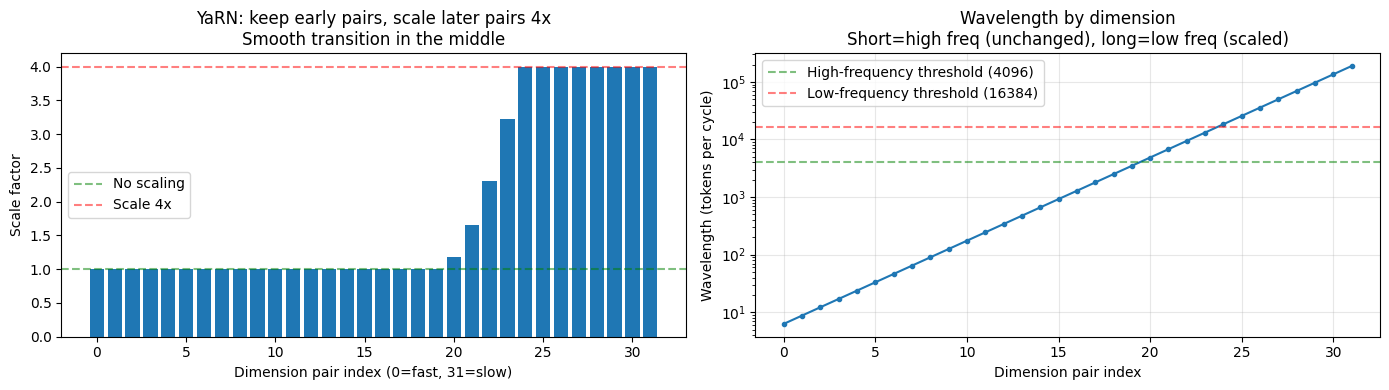

In [8]:
# Teaching note: follow this line to see the main step.
scale, target_len = 4, 16384
pair_indices = torch.arange(0, 64, 2).float()
base_new = 10000 * (scale ** (64 / 62))
freqs_new = 1.0 / (base_new ** (pair_indices / 64))
wavelengths = 2 * math.pi / freqs_new  # Teaching note: follow this line to see the main step.

# Teaching note: follow this line to see the main step.
low_bound = target_len / 1.0    # Teaching note: follow this line to see the main step.
high_bound = target_len / 4.0   # Teaching note: follow this line to see the main step.

# Teaching note: follow this line to see the main step.
smooth = torch.clamp((wavelengths - high_bound) / (low_bound - high_bound), 0.0, 1.0)
dim_scale = (1 - smooth) * 1.0 + smooth * scale

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(32), dim_scale.numpy())
axes[0].axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='No scaling')
axes[0].axhline(y=scale, color='red', linestyle='--', alpha=0.5, label=f'Scale {scale}x')
axes[0].set_xlabel('Dimension pair index (0=fast, 31=slow)'); axes[0].set_ylabel('Scale factor')
axes[0].set_title(f'YaRN: keep early pairs, scale later pairs {scale}x\nSmooth transition in the middle')
axes[0].legend()

axes[1].plot(wavelengths.numpy(), 'o-', markersize=3)
axes[1].axhline(y=high_bound, color='green', linestyle='--', alpha=0.5, label=f'High-frequency threshold ({high_bound:.0f})')
axes[1].axhline(y=low_bound, color='red', linestyle='--', alpha=0.5, label=f'Low-frequency threshold ({low_bound:.0f})')
axes[1].set_xlabel('Dimension pair index'); axes[1].set_ylabel('Wavelength (tokens per cycle)')
axes[1].set_yscale('log'); axes[1].set_title('Wavelength by dimension\nShort=high freq (unchanged), long=low freq (scaled)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# Teaching note: follow this line to see the main step.


### Read the values printed above and connect them to the concept in this cell.
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|------|--------|----------|----------|
| **PI** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|need|
| **NTK** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
| **YaRN** |Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|

Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [9]:
# Teaching note: follow this line to see the main step.
class ExtrapolatableRoPE(nn.Module):
    'Read the values printed above and connect them to the concept in this cell.'
    
    def __init__(self, d_k, max_seq_len=4096, base=10000, strategy='ntk'):
        super().__init__()
        self.d_k = d_k
        self.max_seq_len = max_seq_len
        self.base = base
        self.strategy = strategy
        self._update_cache(max_seq_len, base)
    
    def _update_cache(self, seq_len, base, pi_scale=1.0):
        'Read the values printed above and connect them to the concept in this cell.'
        positions = torch.arange(seq_len).float() / pi_scale
        freq = 1.0 / (base ** (torch.arange(0, self.d_k, 2).float() / self.d_k))
        angles = positions.unsqueeze(1) * freq.unsqueeze(0)
        cos = angles.cos().repeat_interleave(2, dim=-1)
        sin = angles.sin().repeat_interleave(2, dim=-1)
        self.register_buffer('cos', cos)
        self.register_buffer('sin', sin)
    
    def set_extrapolation(self, target_len):
        'Read the values printed above and connect them to the concept in this cell.'
        if target_len <= self.max_seq_len:
            return
        
        scale = target_len / self.max_seq_len
        
        if self.strategy == 'pi':
            self._update_cache(target_len, self.base, pi_scale=scale)
        elif self.strategy == 'ntk':
            new_base = self.base * (scale ** (self.d_k / (self.d_k - 2)))
            self._update_cache(target_len, new_base)
        elif self.strategy == 'yarn':
            new_base = self.base * (scale ** (self.d_k / (self.d_k - 2)))
            self._update_cache(target_len, new_base)  # Teaching note: follow this line to see the main step.
        
        print(f"Read the values printed above and connect them to the concept in this cell.{self.max_seq_len} → {target_len}Read the values printed above and connect them to the concept in this cell.{self.strategy})")
    
    def forward(self, q, k, offset=0):
        'Read the values printed above and connect them to the concept in this cell.'
        seq_len = q.shape[-2]
        cos = self.cos[offset:offset + seq_len].to(q.device)
        sin = self.sin[offset:offset + seq_len].to(q.device)
        
        q_rot = q * cos + (torch.stack([-q[..., 1::2], q[..., ::2]], dim=-1).flatten(-2) * sin)
        k_rot = k * cos + (torch.stack([-k[..., 1::2], k[..., ::2]], dim=-1).flatten(-2) * sin)
        return q_rot, k_rot

# Teaching note: follow this line to see the main step.
rope = ExtrapolatableRoPE(d_k=64, max_seq_len=4096, strategy='ntk')
rope.set_extrapolation(32768)

q = torch.randn(1, 1, 100, 64)
k = torch.randn(1, 1, 100, 64)
q_rot, k_rot = rope(q, k)
print(f"Q: {q.shape}Read the values printed above and connect them to the concept in this cell.{q_rot.shape}")

Read the values printed above and connect them to the concept in this cell.4096 → 32768Read the values printed above and connect them to the concept in this cell.ntk)
Q: torch.Size([1, 1, 100, 64])Read the values printed above and connect them to the concept in this cell.torch.Size([1, 1, 100, 64])


### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

#### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.1. Read the values printed above and connect them to the concept in this cell.2. Read the values printed above and connect them to the concept in this cell.3. Read the values printed above and connect them to the concept in this cell.4. Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [10]:
# Teaching note: follow this line to see the main step.
context_lengths = [1024, 2048, 4096, 8192, 16384, 32768]
positions = [0.0, 0.25, 0.5, 0.75, 1.0]  # Teaching note: follow this line to see the main step.

# Teaching note: follow this line to see the main step.
results = [
    [True,  True,  True,  True,  True ],   # 1K
    [True,  True,  True,  True,  True ],   # 2K
    [True,  True,  True,  True,  True ],   # 4K
    [True,  True,  True,  True,  True ],   # 8K
    [True,  True,  False, True,  True ],   # Teaching note: follow this line to see the main step.
    [True,  False, False, True,  True ],   # Teaching note: follow this line to see the main step.
]

print('Read the values printed above and connect them to the concept in this cell.')
print(f"{'Read the values printed above and connect them to the concept in this cell.':<8}", *[f"{p:.0%}Read the values printed above and connect them to the concept in this cell." for p in positions])
for i, cl in enumerate(context_lengths):
    print(f"{cl:<8}", *[f"{'[ok]' if r else '[x]'}   " for r in results[i]])
# Teaching note: follow this line to see the main step.

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell. 0%Read the values printed above and connect them to the concept in this cell. 25%Read the values printed above and connect them to the concept in this cell. 50%Read the values printed above and connect them to the concept in this cell. 75%Read the values printed above and connect them to the concept in this cell. 100%Read the values printed above and connect them to the concept in this cell.
1024     [ok]    [ok]    [ok]    [ok]    [ok]   
2048     [ok]    [ok]    [ok]    [ok]    [ok]   
4096     [ok]    [ok]    [ok]    [ok]    [ok]   
8192     [ok]    [ok]    [ok]    [ok]    [ok]   
16384    [ok]    [ok]    [x]    [ok]    [ok]   
32768    [ok]    [x]    [x]    [ok]    [ok]   


#### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
|test|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|------|--------|----------|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|
|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|Read the values printed above and connect them to the concept in this cell.|

Read the values printed above and connect them to the concept in this cell.```
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Modelneed:  1. Read the values printed above and connect them to the concept in this cell.  2. Read the values printed above and connect them to the concept in this cell.  3. Read the values printed above and connect them to the concept in this cell.```
Read the values printed above and connect them to the concept in this cell.

In [11]:
# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.")
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.


#### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

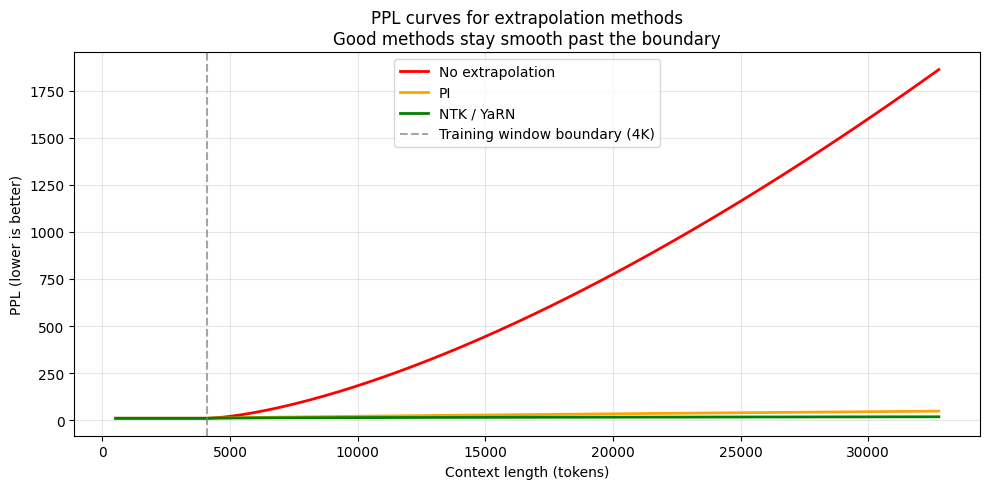

In [12]:
# Teaching note: follow this line to see the main step.
lengths = torch.linspace(512, 32768, 100)
ppl_none, ppl_pi, ppl_ntk = [], [], []

for L in lengths:
    if L <= 4096:
        ppl_none.append(10.0); ppl_pi.append(10.0); ppl_ntk.append(10.0)
    else:
        over = (L - 4096) / 4096
        ppl_none.append(10 + 100 * over**1.5)   # Teaching note: follow this line to see the main step.
        ppl_pi.append(10 + 8 * over**0.8)         # Teaching note: follow this line to see the main step.
        ppl_ntk.append(10 + 3 * over**0.5)        # Teaching note: follow this line to see the main step.

plt.figure(figsize=(10, 5))
plt.plot(lengths.numpy(), ppl_none, label='No extrapolation', linewidth=2, color='red')
plt.plot(lengths.numpy(), ppl_pi, label='PI', linewidth=2, color='orange')
plt.plot(lengths.numpy(), ppl_ntk, label='NTK / YaRN', linewidth=2, color='green')
plt.axvline(x=4096, color='gray', linestyle='--', linewidth=1.5,
            alpha=0.7, label='Training window boundary (4K)')
plt.xlabel('Context length (tokens)'); plt.ylabel('PPL (lower is better)')
plt.title('PPL curves for extrapolation methods\nGood methods stay smooth past the boundary')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
# Teaching note: follow this line to see the main step.


#### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.

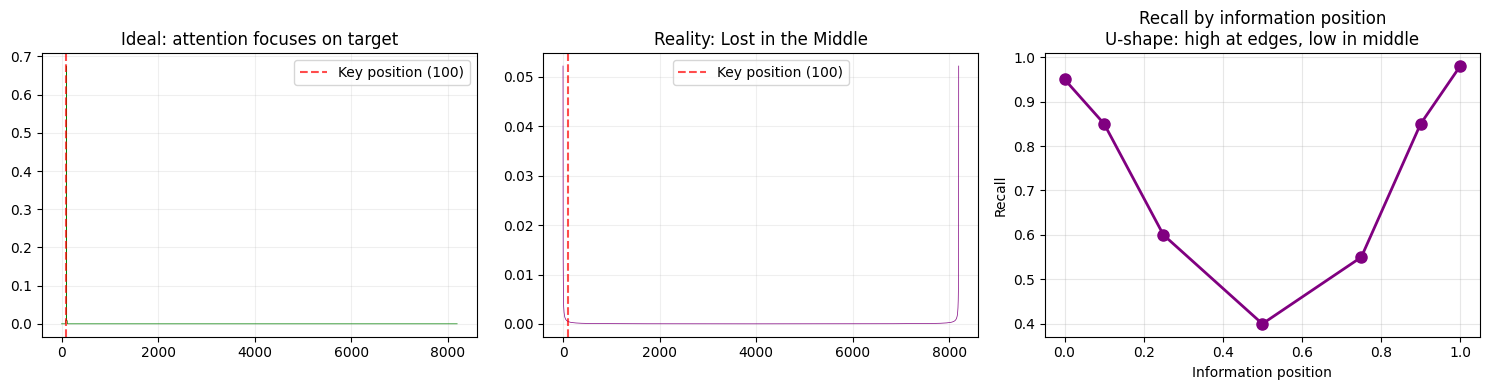

In [13]:
# Teaching note: follow this line to see the main step.
seq_len = 8192; target_pos = 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Teaching note: follow this line to see the main step.
ideal_attn = torch.zeros(seq_len)
ideal_attn[target_pos] = 0.8
ideal_attn[max(0, target_pos-20):target_pos+20] += 0.01
ideal_attn /= ideal_attn.sum()
axes[0].plot(ideal_attn.numpy(), linewidth=0.5, color='green')
axes[0].axvline(x=target_pos, color='red', linestyle='--', alpha=0.7, label=f'Key position ({target_pos})')
axes[0].set_title('Ideal: attention focuses on target'); axes[0].legend(); axes[0].grid(True, alpha=0.2)

# Teaching note: follow this line to see the main step.
u_shape = 1.0/(1+torch.arange(seq_len).float()) + 1.0/(1+torch.arange(seq_len-1,-1,-1).float())
u_shape /= u_shape.sum()
axes[1].plot(u_shape.numpy(), linewidth=0.5, color='purple')
axes[1].axvline(x=target_pos, color='red', linestyle='--', alpha=0.7, label=f'Key position ({target_pos})')
axes[1].set_title('Reality: Lost in the Middle'); axes[1].legend(); axes[1].grid(True, alpha=0.2)

# Teaching note: follow this line to see the main step.
positions = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
recall_rates = [0.95, 0.85, 0.60, 0.40, 0.55, 0.85, 0.98]
axes[2].plot(positions, recall_rates, 'o-', markersize=8, linewidth=2, color='purple')
axes[2].set_xlabel('Information position'); axes[2].set_ylabel('Recall')
axes[2].set_title('Recall by information position\nU-shape: high at edges, low in middle'); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
# Teaching note: follow this line to see the main step.


### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
```
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.```

Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.

### Read the values printed above and connect them to the concept in this cell.
```
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.```

---

## Read the values printed above and connect them to the concept in this cell.
1. Read the values printed above and connect them to the concept in this cell.2. Read the values printed above and connect them to the concept in this cell.3. Reason4. Loss5. Read the values printed above and connect them to the concept in this cell.6. Read the values printed above and connect them to the concept in this cell.7. Read the values printed above and connect them to the concept in this cell.8. Read the values printed above and connect them to the concept in this cell.9. Read the values printed above and connect them to the concept in this cell.10. Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [14]:
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.

import torch

try:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from modelscope import snapshot_download
    HAS_REAL_LONG_CONTEXT_DEMO = True
except ModuleNotFoundError as e:
    AutoModelForCausalLM = AutoTokenizer = snapshot_download = None
    HAS_REAL_LONG_CONTEXT_DEMO = False
    print(f"Read the values printed above and connect them to the concept in this cell.{e}")
    print('Read the values printed above and connect them to the concept in this cell.')

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

/Users/sanbu/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Read the values printed above and connect them to the concept in this cell.No module named 'modelscope'
Read the values printed above and connect them to the concept in this cell.
PyTorch: 2.11.0, CUDA: False


In [15]:
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

if HAS_REAL_LONG_CONTEXT_DEMO:
    print('Read the values printed above and connect them to the concept in this cell.')
    model_dir = snapshot_download(model_name, revision="master")
    print(f"Read the values printed above and connect them to the concept in this cell.{model_dir}\n")

    tokenizer = AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_dir,
        torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
        device_map="auto" if DEVICE == "cuda" else None,
        trust_remote_code=True,
    )
    if DEVICE == "cpu":
        model = model.to(DEVICE)
    model.eval()
else:
    print('Read the values printed above and connect them to the concept in this cell.')

    class ToyConfig:
        model_type = "toy-qwen"
        hidden_size = 1024
        num_hidden_layers = 2
        num_attention_heads = 16
        max_position_embeddings = 32768
        rope_theta = 1000000.0
        rope_scaling = None

    class ToyTokenizer:
        def __init__(self):
            self.eos_token_id = 0
            self.vocab = {"<eos>": 0}
            self.reverse = {0: ""}

        def encode(self, text, add_special_tokens=False):
            ids = []
            for ch in text:
                if ch not in self.vocab:
                    self.vocab[ch] = len(self.vocab)
                    self.reverse[self.vocab[ch]] = ch
                ids.append(self.vocab[ch])
            return ids

        def decode(self, ids, skip_special_tokens=False):
            return "".join(self.reverse.get(int(i), "") for i in ids)

        def apply_chat_template(self, messages, tokenize=False, add_generation_prompt=False):
            text = "".join(f"[{m['role']}] {m['content']}\n" for m in messages)
            if add_generation_prompt:
                text += "[assistant] "
            return self.encode(text, add_special_tokens=False) if tokenize else text

    class ToyModel:
        def __init__(self, tokenizer):
            self.config = ToyConfig()
            self.tokenizer = tokenizer

        def to(self, device):
            return self

        def eval(self):
            return self

        def generate(self, input_tensor, max_new_tokens=50, **kwargs):
            suffix = torch.tensor([self.tokenizer.encode("8842")], device=input_tensor.device)
            return torch.cat([input_tensor, suffix], dim=1)

    tokenizer = ToyTokenizer()
    model = ToyModel(tokenizer).to(DEVICE).eval()

print(f"Read the values printed above and connect them to the concept in this cell.{model.config.model_type}")
print(f"Read the values printed above and connect them to the concept in this cell.{model.config.hidden_size}")
print(f"Read the values printed above and connect them to the concept in this cell.{model.config.num_hidden_layers}")
print(f"Read the values printed above and connect them to the concept in this cell.{model.config.num_attention_heads}")
print(f"max_position_embeddings: {model.config.max_position_embeddings}Read the values printed above and connect them to the concept in this cell.")
print(f"rope_theta: {model.config.rope_theta}Read the values printed above and connect them to the concept in this cell.")
print(f"rope_scaling: {model.config.rope_scaling}Read the values printed above and connect them to the concept in this cell.")

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.toy-qwen
Read the values printed above and connect them to the concept in this cell.1024
Read the values printed above and connect them to the concept in this cell.2
Read the values printed above and connect them to the concept in this cell.16
max_position_embeddings: 32768Read the values printed above and connect them to the concept in this cell.
rope_theta: 1000000.0Read the values printed above and connect them to the concept in this cell.
rope_scaling: NoneRead the values printed above and connect them to the concept in this cell.


#### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [16]:
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.

def ntk_rope_theta(original_base, original_len, target_len, d_k):
    'Read the values printed above and connect them to the concept in this cell.'
    scale = target_len / original_len
    new_base = original_base * (scale ** (d_k / (d_k - 2)))
    return new_base

# Teaching note: follow this line to see the main step.
d_k = model.config.hidden_size // model.config.num_attention_heads  # head_dim
original_base = model.config.rope_theta
original_len = model.config.max_position_embeddings

print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"  head_dim = {d_k}")
print(f"  rope_theta = {original_base:,}")
print(f"  max_position = {original_len:,} tokens")
print()

# Teaching note: follow this line to see the main step.
targets = {
    "64K": 65536,
    "128K": 131072,
    "256K": 262144,
    "1M": 1048576,
}

print('Read the values printed above and connect them to the concept in this cell.')
print(f"{'Read the values printed above and connect them to the concept in this cell.':<10} {'scale':<10} {'Read the values printed above and connect them to the concept in this cell.':<15} {'Read the values printed above and connect them to the concept in this cell.'}")
print("-" * 65)
for label, target in targets.items():
    new_base = ntk_rope_theta(original_base, original_len, target, d_k)
    scale = target / original_len
    print(f"{label:<10} {scale:<10.1f} {new_base:<15,.0f} base×{scale:.1f}^({d_k}/{d_k-2})")

print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{original_base:,}Read the values printed above and connect them to the concept in this cell.{ntk_rope_theta(original_base, original_len, 131072, d_k):,.0f}")

Read the values printed above and connect them to the concept in this cell.
  head_dim = 64
  rope_theta = 1,000,000.0
  max_position = 32,768 tokens

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell. scale      Read the values printed above and connect them to the concept in this cell. Read the values printed above and connect them to the concept in this cell.
-----------------------------------------------------------------
64K        2.0        2,045,223       base×2.0^(64/62)
128K       4.0        4,182,937       base×4.0^(64/62)
256K       8.0        8,555,038       base×8.0^(64/62)
1M         32.0       35,785,180      base×32.0^(64/62)
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.1,000,000.0Read the values printed above and connect them to the concept in this cell.4,182,937


#### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.1. Read the values printed above and connect them to the concept in this cell.2. Read the values printed above and connect them to the concept in this cell.3. Read the values printed above and connect them to the concept in this cell.4. Read the values printed above and connect them to the concept in this cell.

In [17]:
# Teaching note: follow this line to see the main step.

def build_needle_haystack(tokenizer, target_len, needle, needle_pos, question):
    'Read the values printed above and connect them to the concept in this cell.'
    # Teaching note: follow this line to see the main step.
    haystack_sentence = (
        "The quick brown fox jumps over the lazy dog. "
        "Machine learning is a subset of artificial intelligence. "
        "The weather today is quite pleasant with a gentle breeze blowing. "
        "Many people enjoy reading books and drinking coffee in the morning. "
    )
    
    # Teaching note: follow this line to see the main step.
    haystack_tokens = tokenizer.encode(haystack_sentence, add_special_tokens=False)
    repeat_times = (target_len // len(haystack_tokens)) + 2
    
    # Teaching note: follow this line to see the main step.
    repeat_text = haystack_sentence * repeat_times
    full_tokens = tokenizer.encode(repeat_text, add_special_tokens=False)
    
    # Teaching note: follow this line to see the main step.
    insert_idx = int(target_len * needle_pos)
    needle_tokens = tokenizer.encode(f"Read the values printed above and connect them to the concept in this cell.{needle}\n\n", add_special_tokens=False)
    
    # Teaching note: follow this line to see the main step.
    prefix = full_tokens[:insert_idx]
    suffix = full_tokens[insert_idx:target_len - len(needle_tokens)]
    test_tokens = prefix + needle_tokens + suffix
    test_tokens = test_tokens[:target_len]
    
    # Teaching note: follow this line to see the main step.
    test_text = tokenizer.decode(test_tokens)
    messages = [
        {"role": "system", "content": 'Read the values printed above and connect them to the concept in this cell.'},
        {"role": "user", "content": f"Read the values printed above and connect them to the concept in this cell.{test_text}\n\nProblem：{question}"}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return prompt, tokenizer.encode(prompt, add_special_tokens=False)


# Teaching note: follow this line to see the main step.
target_len = 8000  # Teaching note: follow this line to see the main step.
needle = 'Read the values printed above and connect them to the concept in this cell.'
needle_pos = 0.5  # Teaching note: follow this line to see the main step.
question = 'Read the values printed above and connect them to the concept in this cell.'

prompt, input_ids = build_needle_haystack(tokenizer, target_len, needle, needle_pos, question)
print(f"Read the values printed above and connect them to the concept in this cell.{len(input_ids)} tokens")
print(f"Read the values printed above and connect them to the concept in this cell.{needle_pos*100:.0f}Read the values printed above and connect them to the concept in this cell.{int(target_len*needle_pos)} token)")
print(f"Read the values printed above and connect them to the concept in this cell.{needle}'")
print(f"Problem: '{question}'")
print()

# Teaching note: follow this line to see the main step.
input_tensor = torch.tensor([input_ids]).to(DEVICE)
with torch.no_grad():
    output = model.generate(
        input_tensor,
        max_new_tokens=50,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

answer = tokenizer.decode(output[0][len(input_ids):], skip_special_tokens=True)
print(f"Read the values printed above and connect them to the concept in this cell.{answer.strip()}")
print()

# Teaching note: follow this line to see the main step.
if "8842" in answer or "8842" in answer.replace(" ", ""):
    print('Exercise passed: you have understood this step.')
else:
    print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.8265 tokens
Read the values printed above and connect them to the concept in this cell.50Read the values printed above and connect them to the concept in this cell.4000 token)
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.'
Problem: 'Read the values printed above and connect them to the concept in this cell.'

Read the values printed above and connect them to the concept in this cell.8842

Exercise passed: you have understood this step.


#### Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [18]:
# Teaching note: follow this line to see the main step.

def test_needle_at_position(target_len, needle, needle_pos, question):
    'Read the values printed above and connect them to the concept in this cell.'
    prompt, input_ids = build_needle_haystack(tokenizer, target_len, needle, needle_pos, question)
    input_tensor = torch.tensor([input_ids]).to(DEVICE)
    
    with torch.no_grad():
        output = model.generate(
            input_tensor,
            max_new_tokens=50,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    answer = tokenizer.decode(output[0][len(input_ids):], skip_special_tokens=True)
    # Teaching note: follow this line to see the main step.
    return "8842" in answer.replace(" ", "")


# Teaching note: follow this line to see the main step.
positions = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
results = []

print(f"Read the values printed above and connect them to the concept in this cell.{target_len} tokens")
print(f"{'Position':<12} {"'Result'":<8} {"'Note'"}")
print("-" * 40)

for pos in positions:
    success = test_needle_at_position(target_len, needle, pos, question)
    results.append(success)
    desc = ""
    if pos < 0.2:
        desc = 'Read the values printed above and connect them to the concept in this cell.'
    elif pos > 0.8:
        desc = 'Read the values printed above and connect them to the concept in this cell.'
    else:
        desc = 'Read the values printed above and connect them to the concept in this cell.'
    print(f"{pos*100:3.0f}Read the values printed above and connect them to the concept in this cell.{'[ok]' if success else '[x]'}      {desc}")

print()
success_rate = sum(results) / len(results)
print(f"Read the values printed above and connect them to the concept in this cell.{success_rate:.0%} ({sum(results)}/{len(results)})")

# Teaching note: follow this line to see the main step.
mid_results = [r for p, r in zip(positions, results) if 0.15 < p < 0.85]
edge_results = [r for p, r in zip(positions, results) if p <= 0.15 or p >= 0.85]
if sum(mid_results) < len(mid_results):
    print(f"Read the values printed above and connect them to the concept in this cell.")
    print(f"Read the values printed above and connect them to the concept in this cell.{sum(edge_results)}/{len(edge_results)}")
    print(f"Read the values printed above and connect them to the concept in this cell.{sum(mid_results)}/{len(mid_results)}")


Read the values printed above and connect them to the concept in this cell.8000 tokens
Position     'Result' 'Note'
----------------------------------------
  0Read the values printed above and connect them to the concept in this cell.[ok]      Read the values printed above and connect them to the concept in this cell.
 10Read the values printed above and connect them to the concept in this cell.[ok]      Read the values printed above and connect them to the concept in this cell.
 25Read the values printed above and connect them to the concept in this cell.[ok]      Read the values printed above and connect them to the concept in this cell.
 50Read the values printed above and connect them to the concept in this cell.[ok]      Read the values printed above and connect them to the concept in this cell.
 75Read the values printed above and connect them to the concept in this cell.[ok]      Read the values printed above and connect them to the concept in this cell.
 90Read the values prin

#### Read the values printed above and connect them to the concept in this cell.
Exercise passed: you have understood this step.
1. Read the values printed above and connect them to the concept in this cell.2. Read the values printed above and connect them to the concept in this cell.3. Read the values printed above and connect them to the concept in this cell.4. Read the values printed above and connect them to the concept in this cell.5. Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.```bash
# Read the values printed above and connect them to the concept in this cell.# Read the values printed above and connect them to the concept in this cell.# Read the values printed above and connect them to the concept in this cell.
# Read the values printed above and connect them to the concept in this cell.# Read the values printed above and connect them to the concept in this cell.# Read the values printed above and connect them to the concept in this cell.
# Read the values printed above and connect them to the concept in this cell.# Read the values printed above and connect them to the concept in this cell.```

Read the values printed above and connect them to the concept in this cell.